--- DATASET SHAPE ---
(7043, 21)

--- FIRST 5 ROWS ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechS

/tmp/ipykernel_750/712671201.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


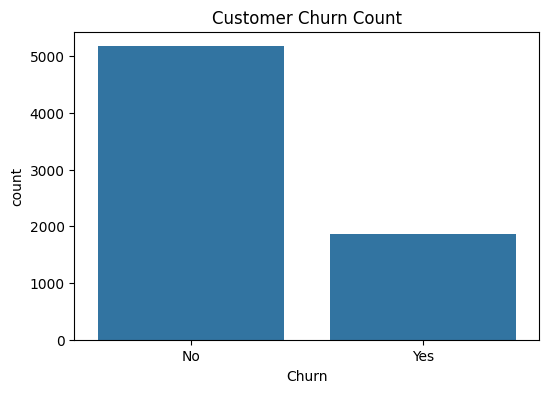

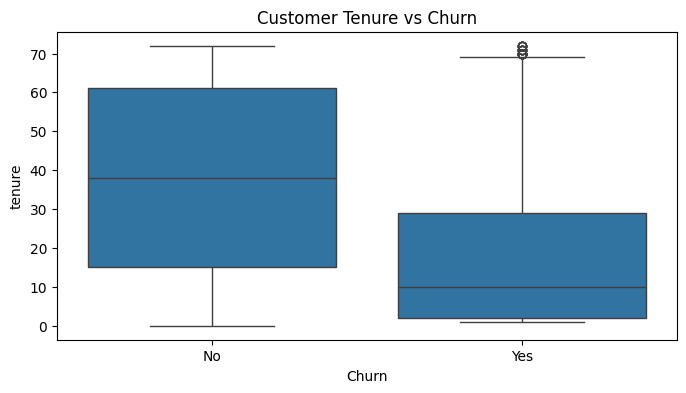

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



================ Logistic Regression ================
Accuracy:  0.8041
Precision: 0.6541
Recall:    0.5561
F1-Score:  0.6012

Confusion Matrix:
[[925 110]
 [166 208]]

================ Random Forest ================
Accuracy:  0.7864
Precision: 0.6237
Recall:    0.4920
F1-Score:  0.5501

Confusion Matrix:
[[924 111]
 [190 184]]

Sample Prediction Output: No Churn (Customer nahi jayega)


In [1]:

# ==========================================
# STEP 1: DATA LOADING AND UNDERSTANDING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Direct Online Source se Dataset Load Karna
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("--- DATASET SHAPE ---")
print(df.shape)

print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- TARGET VARIABLE (CHURN) DISTRIBUTION ---")
print(df['Churn'].value_counts())

# ==========================================
# STEP 2: DATA PREPROCESSING
# ==========================================
# TotalCharges ko numeric format mein convert aur missing values fill karna
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Duplicate rows aur unnecessary column (customerID) drop karna
df.drop_duplicates(inplace=True)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# ==========================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Count')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Customer Tenure vs Churn')
plt.show()

# ==========================================
# STEP 4: FEATURE ENGINEERING AND ENCODING
# ==========================================
# Target Variable Encoding (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Inputs (X) aur Target (y) Split
X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn']

# ==========================================
# STEP 5: MODEL TRAINING & EVALUATION
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models Train Karna
lr_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# Evaluation
models = {'Logistic Regression': lr_model, 'Random Forest': rf_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n================ {name} ================")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# ==========================================
# STEP 6: SAMPLE PREDICTION
# ==========================================
sample_data = X_test.iloc[[0]]
sample_pred = rf_model.predict(sample_data)[0]

status = "Churn (Customer leave karega)" if sample_pred == 1 else "No Churn (Customer nahi jayega)"
print(f"\nSample Prediction Output: {status}")